In [1]:
import matplotlib.pyplot as plt
import mplscience
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy

## Extended Data Figure 10e-h

In [2]:
signatures = {
	'Collagen': ["ACTA2", "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL12A1"],
	'HALLMARK_TGF_BETA_SIGNALING': ["ACVR1", "APC", "ARID4B", "BCAR3", "BMP2", "BMPR1A", "BMPR2", "CDH1", "CDK9", "CDKN1C", "CTNNB1", "ENG", "FKBP1A", "FNTA", "FURIN", "HDAC1", "HIPK2", "ID1", "ID2", "ID3", "IFNGR2", "JUNB", "KLF10", "LEFTY2", "LTBP2", "MAP3K7", "NCOR2", "NOG", "PMEPA1", "PPM1A", "PPP1CA", "PPP1R15A", "RAB31", "RHOA", "SERPINE1", "SKI", "SKIL", "SLC20A1", "SMAD1", "SMAD3", "SMAD6", "SMAD7", "SMURF1", "SMURF2", "SPTBN1", "TGFB1", "TGFBR1", "TGIF1", "THBS1", "TJP1", "TRIM33", "UBE2D3", "WWTR1", "XIAP"],
	'HALLMARK_HYPOXIA': ["ACKR3", "ADM", "ADORA2B", "AK4", "AKAP12", "ALDOA", "ALDOB", "ALDOC", "AMPD3", "ANGPTL4", "ANKZF1", "ANXA2", "ATF3", "ATP7A", "B3GALT6", "B4GALNT2", "BCAN", "BCL2", "BGN", "BHLHE40", "BNIP3L", "BRS3", "BTG1", "CA12", "CASP6", "CAV1", "CAVIN1", "CAVIN3", "CCN1", "CCN2", "CCN5", "CCNG2", "CDKN1A", "CDKN1B", "CDKN1C", "CHST2", "CHST3", "CITED2", "COL5A1", "CP", "CSRP2", "CXCR4", "DCN", "DDIT3", "DDIT4", "DPYSL4", "DTNA", "DUSP1", "EDN2", "EFNA1", "EFNA3", "EGFR", "ENO1", "ENO2", "ENO3", "ERO1A", "ERRFI1", "ETS1", "EXT1", "F3", "FAM162A", "FBP1", "FOS", "FOSL2", "FOXO3", "GAA", "GALK1", "GAPDH", "GAPDHS", "GBE1", "GCK", "GCNT2", "GLRX", "GPC1", "GPC3", "GPC4", "GPI", "GRHPR", "GYS1", "HAS1", "HDLBP", "HEXA", "HK1", "HK2", "HMOX1", "HOXB9", "HS3ST1", "HSPA5", "IDS", "IER3", "IGFBP1", "IGFBP3", "IL6", "ILVBL", "INHA", "IRS2", "ISG20", "JMJD6", "JUN", "KDELR3", "KDM3A", "KIF5A", "KLF6", "KLF7", "KLHL24", "LALBA", "LARGE1", "LDHA", "LDHC", "LOX", "LXN", "MAFF", "MAP3K1", "MIF", "MT1E", "MT2A", "MXI1", "MYH9", "NAGK", "NCAN", "NDRG1", "NDST1", "NDST2", "NEDD4L", "NFIL3", "NOCT", "NR3C1", "P4HA1", "P4HA2", "PAM", "PCK1", "PDGFB", "PDK1", "PDK3", "PFKFB3", "PFKL", "PFKP", "PGAM2", "PGF", "PGK1", "PGM1", "PGM2", "PHKG1", "PIM1", "PKLR", "PKP1", "PLAC8", "PLAUR", "PLIN2", "PNRC1", "PPARGC1A", "PPFIA4", "PPP1R15A", "PPP1R3C", "PRDX5", "PRKCA", "PYGM", "RBPJ", "RORA", "RRAGD", "S100A4", "SAP30", "SCARB1", "SDC2", "SDC3", "SDC4", "SELENBP1", "SERPINE1", "SIAH2", "SLC25A1", "SLC2A1", "SLC2A3", "SLC2A5", "SLC37A4", "SLC6A6", "SRPX", "STBD1", "STC1", "STC2", "SULT2B1", "TES", "TGFB3", "TGFBI", "TGM2", "TIPARP", "TKTL1", "TMEM45A", "TNFAIP3", "TPBG", "TPD52", "TPI1", "TPST2", "UGP2", "VEGFA", "VHL", "VLDLR", "WSB1", "XPNPEP1", "ZFP36", "ZNF292"],
	'HALLMARK_MYOGENESIS': ["ABLIM1", "ACHE", "ACSL1", "ACTA1", "ACTC1", "ACTN2", "ACTN3", "ADAM12", "ADCY9", "AEBP1", "AGL", "AGRN", "AK1", "AKT2", "ANKRD2", "APLNR", "APOD", "APP", "ATP2A1", "ATP6AP1", "BAG1", "BDKRB2", "BHLHE40", "BIN1", "CACNA1H", "CACNG1", "CAMK2B", "CASQ1", "CASQ2", "CAV3", "CD36", "CDH13", "CDKN1A", "CFD", "CHRNA1", "CHRNB1", "CHRNG", "CKB", "CKM", "CKMT2", "CLU", "CNN3", "COL15A1", "COL1A1", "COL3A1", "COL4A2", "COL6A2", "COL6A3", "COX6A2", "COX7A1", "CRAT", "CRYAB", "CSRP3", "CTF1", "DAPK2", "DENND2B", "DES", "DMD", "DMPK", "DTNA", "EFS", "EIF4A2", "ENO3", "EPHB3", "ERBB3", "FABP3", "FDPS", "FGF2", "FHL1", "FKBP1B", "FLII", "FOXO4", "FST", "FXYD1", "GAA", "GABARAPL2", "GADD45B", "GJA5", "GNAO1", "GPX3", "GSN", "HBEGF", "HDAC5", "HRC", "HSPB2", "HSPB8", "IFRD1", "IGF1", "IGFBP3", "IGFBP7", "ITGA7", "ITGB1", "ITGB4", "ITGB5", "KCNH1", "KCNH2", "KIFC3", "KLF5", "LAMA2", "LARGE1", "LDB3", "LPIN1", "LSP1", "MAPK12", "MAPRE3", "MB", "MEF2A", "MEF2C", "MEF2D", "MRAS", "MYBPC3", "MYBPH", "MYF6", "MYH1", "MYH11", "MYH2", "MYH3", "MYH4", "MYH7", "MYH8", "MYH9", "MYL1", "MYL11", "MYL2", "MYL3", "MYL4", "MYL6B", "MYL7", "MYLK", "MYO1C", "MYOG", "MYOM1", "MYOM2", "MYOZ1", "NAV2", "NCAM1", "NOS1", "NOTCH1", "NQO1", "OCEL1", "PC", "PDE4DIP", "PDLIM7", "PFKM", "PGAM2", "PICK1", "PKIA", "PLXNB2", "PPFIA4", "PPP1R3C", "PRNP", "PSEN2", "PTGIS", "PTP4A3", "PVALB", "PYGM", "RB1", "REEP1", "RIT1", "RYR1", "SCD", "SCHIP1", "SGCA", "SGCD", "SGCG", "SH2B1", "SH3BGR", "SIRT2", "SLC6A8", "SLN", "SMTN", "SOD3", "SORBS1", "SORBS3", "SPARC", "SPDEF", "SPEG", "SPHK1", "SPTAN1", "SSPN", "STC2", "SVIL", "SYNGR2", "TAGLN", "TCAP", "TEAD4", "TGFB1", "TNNC1", "TNNC2", "TNNI1", "TNNI2", "TNNT1", "TNNT2", "TNNT3", "TPD52L1", "TPM2", "TPM3", "TSC2", "VIPR1", "WWTR1"]
}

other_genes = ['ARG1', 'SPP1', 'C1QB', 'TGFB1', 'SLC2A1', 'VIM', 'HMGA2', 'TWIST1', 'SNAI2', 'ZEB2', 'CD44', 'COL3A1']

In [3]:
data_dir = "/path/to/Xing2025"
full_obj = sc.read_h5ad(f"{data_dir}/lc.h5ad")
meta_data = pd.read_csv(f"{data_dir}/lc_meta.tsv", sep='\t',index_col = 0)

In [4]:
full_obj.X = full_obj.X.tocsc()

In [5]:
full_obj.obs = full_obj.obs.join(meta_data, how='left')

In [6]:
# normalize
sc.pp.normalize_total(full_obj, target_sum=1e6)
sc.pp.log1p(full_obj)

# sc.pp.scale(full_obj, max_value=10)

In [7]:
full_obj[full_obj.obs['CancerSubtype'] == 'NSCLC-LUAD',:].obs['Treatment'].value_counts()

Treatment
Naive      295183
Treated     20873
Name: count, dtype: int64

In [8]:
luad_only = full_obj[(full_obj.obs['CancerSubtype'] == 'NSCLC-LUAD') & (full_obj.obs['Treatment'] == 'Naive'),:]

In [9]:
full_obj[(full_obj.obs['CancerType'] == 'LC')].obs[['SampleID', 'Treatment', 'compartment']].drop_duplicates().groupby(['Treatment', 'compartment']).size()

Treatment  compartment
Naive      BM             45
           PT             26
Treated    BM              9
           PT              5
dtype: int64

In [ ]:
sc.pp.scale(luad_only)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
luad_only.obs.head(5)

In [ ]:
len(luad_only.obs['SampleID'].unique())

In [ ]:
luad_only.obs[['compartment', 'SampleID']].drop_duplicates().groupby('compartment').size()

Collagen


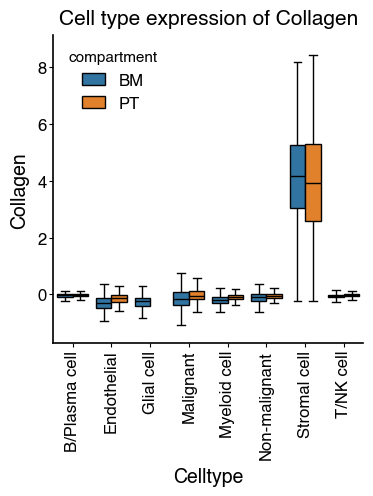

HALLMARK_TGF_BETA_SIGNALING


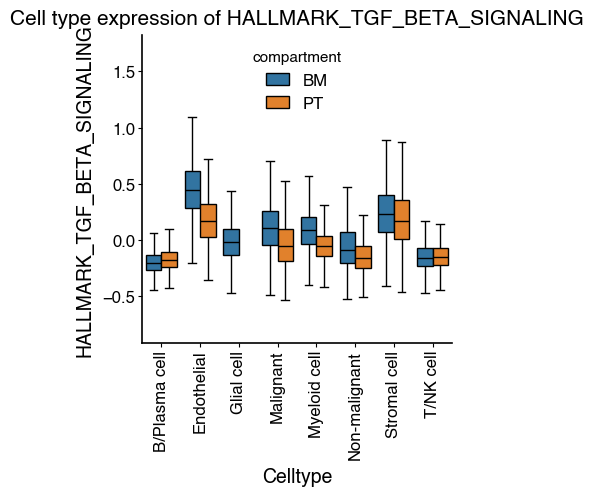

HALLMARK_HYPOXIA


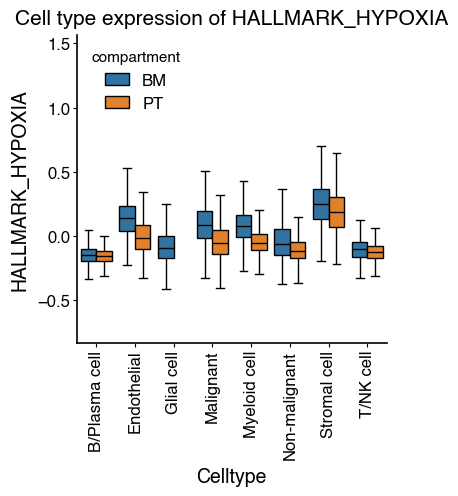

HALLMARK_MYOGENESIS


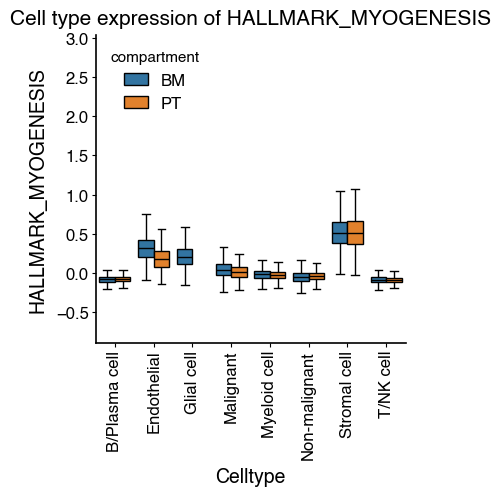

In [30]:
# for signature in signatures:

for signature in signatures:
    genes = signatures[signature]
    print(signature)
    
    sc.tl.score_genes(luad_only, genes, ctrl_size=50, n_bins=25, score_name=signature, use_raw=False)
    with mplscience.style_context():
    
        sns.boxplot(data=luad_only.obs, x='Celltype', y=signature, hue='compartment', fliersize=0, linecolor='black')
        # sns.stripplot(data=luad_only.obs, x='Celltype', y=signature, hue='compartment', size=0.5, dodge=True, legend=False)
        plt.xticks(rotation=90)
        plt.title(f'Cell type expression of {signature}')
        # plt.savefig(f"./figures/xing_luad_{signature}_celltype.pdf")
        plt.show()

In [35]:
for signature in signatures:
    for cell_type in luad_only.obs['Celltype'].unique():

        adata_sub = luad_only[luad_only.obs['Celltype'] == cell_type]
        
        brain = adata_sub.obs.loc[adata_sub.obs['compartment'] == 'BM', signature].values
        pt = adata_sub.obs.loc[adata_sub.obs['compartment'] == 'PT', signature].values
        
        pval = scipy.stats.ranksums(brain, pt, alternative='greater')[1]
    
        print(f'{cell_type}, {signature} Pvalue: {round(pval, 3)}')

    print('-----')

Myeloid cell, Collagen Pvalue: 1.0
Non-malignant, Collagen Pvalue: 1.0
T/NK cell, Collagen Pvalue: 1.0
B/Plasma cell, Collagen Pvalue: 1.0
Stromal cell, Collagen Pvalue: 0.002
Endothelial, Collagen Pvalue: 1.0
Malignant, Collagen Pvalue: 1.0
Glial cell, Collagen Pvalue: nan
-----
Myeloid cell, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
Non-malignant, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
T/NK cell, HALLMARK_TGF_BETA_SIGNALING Pvalue: 1.0
B/Plasma cell, HALLMARK_TGF_BETA_SIGNALING Pvalue: 1.0
Stromal cell, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
Endothelial, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
Malignant, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
Glial cell, HALLMARK_TGF_BETA_SIGNALING Pvalue: nan
-----
Myeloid cell, HALLMARK_HYPOXIA Pvalue: 0.0
Non-malignant, HALLMARK_HYPOXIA Pvalue: 0.0
T/NK cell, HALLMARK_HYPOXIA Pvalue: 0.0
B/Plasma cell, HALLMARK_HYPOXIA Pvalue: 0.0
Stromal cell, HALLMARK_HYPOXIA Pvalue: 0.0
Endothelial, HALLMARK_HYPOXIA Pvalue: 0.0
Malignant, HALLMARK_HYPOXIA Pval

In [17]:
luad_only.obs['cell_type_compartment'] = luad_only.obs.apply(lambda x: f'{x.compartment}_{x.Celltype}', axis=1)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


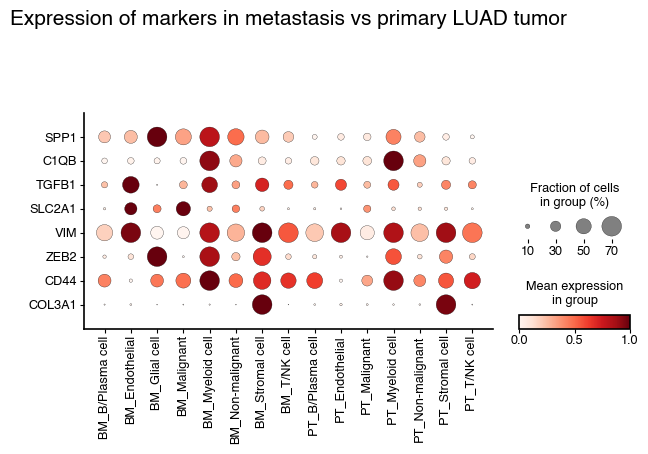

In [21]:
other_genes_v2 = ['SPP1', 'C1QB', 'TGFB1', 'SLC2A1', 'VIM', 'ZEB2', 'CD44', 'COL3A1']

with mplscience.style_context():
    sc.pl.dotplot(
        luad_only,
        # luad_only[luad_only.obs['Celltype'] == celltype,:].copy(),
        var_names=other_genes_v2,
        groupby='cell_type_compartment',
        dot_max=0.7,
        use_raw=False,
        standard_scale='var',
        show=False,
        swap_axes=True,
        title=f"Expression of markers in metastasis vs primary LUAD tumor"
    )
    plt.show()
